title: "Practice Activity 7.2: Penalized Regression"
author: Lily

**GitHub Repository**: <https://github.com/lilysteinberg/GSB-544---Computing-and-ML/tree/main/Week%206>

In [66]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV

In [67]:
ames = pd.read_csv("AmesHousing.csv")
ames

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [68]:
# Get rid of columns with mostly NaN values
good_cols = ames.isna().sum() < 100
ames = ames.loc[:,good_cols]

# Drop other NAs
ames = ames.dropna()

In [69]:
# specify x variables and y variable
X = ames.drop(["SalePrice", "Order", "PID"], axis = 1)
y = ames["SalePrice"]

# Part 1

In [70]:
# build column transformer to treat variables
ct = ColumnTransformer(
  [
    ("dummify",
    OneHotEncoder(sparse_output = False, handle_unknown='ignore'),
    make_column_selector(dtype_include=object)), # can select based on type
    ("standardize",
    StandardScaler(),
    make_column_selector(dtype_include=np.number)) # can select based on type
  ],
  remainder = "passthrough"
).set_output(transform="pandas")

In [71]:
# run as a linear regression
lr_pipeline_1 = Pipeline(
  [("preprocessing", ct),
  ("linear_regression", LinearRegression())]
)

In [72]:
# save fitted linear regression
lr_pipeline_1_fitted = lr_pipeline_1.fit(X, y)

lr_pipeline_1_fitted

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b9aeeb4c890>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b9aeeb4c6e0>)])),
                ('linear_regression', LinearRegression())])

In [73]:
# run as a ridge regression
ridge_pipeline = Pipeline(
  [("preprocessing", ct),
  ("ridge_regression", Ridge(alpha=1))]
)

In [74]:
# find average r-squared for ridge using cross-validation
cross_val_score(ridge_pipeline, X, y, cv = 5, scoring = 'r2')

array([0.89815807, 0.91744024, 0.79493606, 0.78522563, 0.91389818])

In [75]:
# save fitted ridge regression
ridge_pipeline_fitted = ridge_pipeline.fit(X, y)

ridge_pipeline_fitted

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b9aeeb4c890>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b9aeeb4c6e0>)])),
                ('ridge_regression', Ridge(alpha=1))])

In [76]:
# compare between linear regression and ridge regression coefficients
# make new dataframe
coef_compare = pd.DataFrame()

# add columns for linear regression, ridge regression, and the difference
coef_compare["lr"] = lr_pipeline_1_fitted.named_steps['linear_regression'].coef_
coef_compare["ridge"] = ridge_pipeline_fitted.named_steps['ridge_regression'].coef_
coef_compare["ridge__lr_diff"] = coef_compare["ridge"] - coef_compare["lr"]

coef_compare.sort_values(by = "ridge__lr_diff")

,lr,ridge,ridge__lr_diff
93,119504.966230,32582.552859,-86922.413371
94,109059.255835,28387.663156,-80671.592679
37,127054.304996,66530.685838,-60523.619159
69,64910.291903,24567.527777,-40342.764126
95,55399.766568,16828.505080,-38571.261487
...,...,...,...
124,-17416.886121,-6826.403541,10590.482579
85,-20968.886474,-6399.635769,14569.250704
106,-33825.937758,-16633.220977,17192.716782
68,-113384.181772,-77996.160321,35388.021451


<Axes: xlabel='lr', ylabel='ridge'>

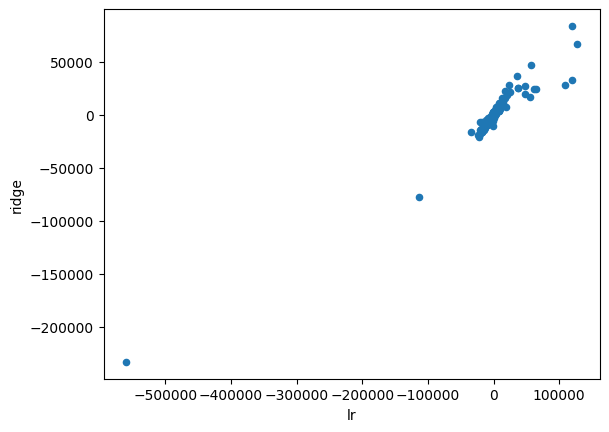

In [77]:
# plot coefficients where scale of axes corresponds to each type of regression
coef_compare.plot.scatter(x="lr", y = "ridge")

# Part 2

In [78]:
# make pipeline for tuning ridge regresssion's lambda
ridge_pipeline_1 = Pipeline(
  [("preprocessing", ct),
  ("ridge_regression", Ridge())]
).set_output(transform="pandas")

alphas = {'ridge_regression__alpha': np.array([0.001, 0.01, 0.1, 1, 10, 100])}
# thinking on a log scale, orders of magnitude

gscv = GridSearchCV(ridge_pipeline_1, param_grid=alphas, cv = 5, scoring='r2')

In [79]:
# feed in data
gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

{'mean_fit_time': array([0.09707747, 0.10830078, 0.1191793 , 0.11817741, 0.11218696,
        0.21005177]),
 'std_fit_time': array([0.01971153, 0.02748156, 0.0339553 , 0.03916113, 0.04066642,
        0.05365373]),
 'mean_score_time': array([0.04597831, 0.04365892, 0.04927578, 0.04383559, 0.06502905,
        0.07882199]),
 'std_score_time': array([0.01767917, 0.01325608, 0.0145309 , 0.01406227, 0.02852186,
        0.00992547]),
 'param_ridge_regression__alpha': masked_array(data=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
              mask=[False, False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'ridge_regression__alpha': np.float64(0.001)},
  {'ridge_regression__alpha': np.float64(0.01)},
  {'ridge_regression__alpha': np.float64(0.1)},
  {'ridge_regression__alpha': np.float64(1.0)},
  {'ridge_regression__alpha': np.float64(10.0)},
  {'ridge_regression__alpha': np.float64(100.0)}],
 'split0_test_score': array([0.8972854 , 0.89734306, 0.89774358, 0.89815807, 0.897762

In [80]:
# view results
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)

df_cv_results_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ridge_regression__alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.097077,0.019712,0.045978,0.017679,0.001,{'ridge_regression__alpha': 0.001},0.897285,0.910406,0.789016,0.772132,0.900762,0.853920,0.060278,6
1,0.108301,0.027482,0.043659,0.013256,0.010,{'ridge_regression__alpha': 0.01},0.897343,0.910614,0.789126,0.772532,0.901317,0.854186,0.060280,5
2,0.119179,0.033955,0.049276,0.014531,0.100,{'ridge_regression__alpha': 0.1},0.897744,0.912306,0.790110,0.775764,0.905587,0.856302,0.060250,4
3,0.118177,0.039161,0.043836,0.014062,1.000,{'ridge_regression__alpha': 1.0},0.898158,0.917440,0.794936,0.785226,0.913898,0.861932,0.059104,2
4,0.112187,0.040666,0.065029,0.028522,10.000,{'ridge_regression__alpha': 10.0},0.897762,0.920812,0.800572,0.787120,0.915095,0.864272,0.058157,1
5,0.210052,0.053654,0.078822,0.009925,100.000,{'ridge_regression__alpha': 100.0},0.887765,0.921979,0.793420,0.772149,0.913554,0.857773,0.062620,3


Lambda = 10 yields the best mean test score.

In [81]:
# run as a ridge regression using best performing lambda to update coefficient comparison table
ridge_pipeline_optimal = Pipeline(
  [("preprocessing", ct),
  ("ridge_regression", Ridge(alpha=10))]
)

In [82]:
# save fitted ridge regression
ridge_pipeline_optimal_fitted = ridge_pipeline_optimal.fit(X, y)

ridge_pipeline_optimal_fitted

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b9aeeb4c890>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b9aeeb4c6e0>)])),
                ('ridge_regression', Ridge(alpha=10))])

In [83]:
# compare between linear regression and ridge regression coefficients

# add columns for linear regression, ridge regression, and the difference
coef_compare["ridge"] = ridge_pipeline_optimal_fitted.named_steps['ridge_regression'].coef_
coef_compare["ridge__lr_diff"] = coef_compare["ridge"] - coef_compare["lr"]

coef_compare.sort_values(by = "ridge__lr_diff")

,lr,ridge,ridge__lr_diff
93,119504.966230,2910.835739,-116594.130491
37,127054.304996,12383.254909,-114671.050088
94,109059.255835,2120.019343,-106939.236492
98,118966.036255,28860.843083,-90105.193172
69,64910.291903,3825.186849,-61085.105054
...,...,...,...
175,-22950.052272,-5704.854592,17245.197680
85,-20968.886474,-3189.258497,17779.627976
106,-33825.937758,-2226.223882,31599.713876
68,-113384.181772,-23831.619604,89552.562168


# Part 3

In [101]:
# make pipeline for tuning lasso regresssion's lambda
lasso_pipeline_1 = Pipeline(
  [("preprocessing", ct),
  ("lasso_regression", Lasso())]
).set_output(transform="pandas")

alphas = {'lasso_regression__alpha': np.array([0.001, 0.01, 0.1, 1, 10, 100])}
# thinking on a log scale, orders of magnitude

gscv = GridSearchCV(lasso_pipeline_1, param_grid=alphas, cv = 5, scoring='r2')

In [102]:
# feed in data
gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.109e+11, tolerance: 1.348e+09
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.466e+11, tolerance: 1.474e+09
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.894e+11, tolerance: 1.463e

{'mean_fit_time': array([1.0794477 , 0.83926854, 1.15908999, 0.69151249, 0.26811213,
        0.24070191]),
 'std_fit_time': array([0.44478748, 0.03473154, 0.5682527 , 0.11146788, 0.10549488,
        0.02748446]),
 'mean_score_time': array([0.03296475, 0.03296776, 0.04216161, 0.03310575, 0.03293748,
        0.03271499]),
 'std_score_time': array([0.00058494, 0.00051387, 0.01470369, 0.0018096 , 0.00129667,
        0.00048314]),
 'param_lasso_regression__alpha': masked_array(data=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
              mask=[False, False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'lasso_regression__alpha': np.float64(0.001)},
  {'lasso_regression__alpha': np.float64(0.01)},
  {'lasso_regression__alpha': np.float64(0.1)},
  {'lasso_regression__alpha': np.float64(1.0)},
  {'lasso_regression__alpha': np.float64(10.0)},
  {'lasso_regression__alpha': np.float64(100.0)}],
 'split0_test_score': array([0.8972019 , 0.89720561, 0.89725821, 0.89774385, 0.900775

In [103]:
# view results
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)

df_cv_results_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lasso_regression__alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.079448,0.444787,0.032965,0.000585,0.001,{'lasso_regression__alpha': 0.001},0.897202,0.910396,0.790320,0.774020,0.905557,0.855499,0.060242,6
1,0.839269,0.034732,0.032968,0.000514,0.010,{'lasso_regression__alpha': 0.01},0.897206,0.910401,0.790859,0.774060,0.905502,0.855606,0.060107,5
2,1.159090,0.568253,0.042162,0.014704,0.100,{'lasso_regression__alpha': 0.1},0.897258,0.910451,0.795951,0.774072,0.905360,0.856618,0.059025,4
3,0.691512,0.111468,0.033106,0.001810,1.000,{'lasso_regression__alpha': 1.0},0.897744,0.910938,0.796918,0.774262,0.905899,0.857152,0.059018,3
4,0.268112,0.105495,0.032937,0.001297,10.000,{'lasso_regression__alpha': 10.0},0.900776,0.915067,0.801420,0.776649,0.909250,0.860632,0.059157,2
5,0.240702,0.027484,0.032715,0.000483,100.000,{'lasso_regression__alpha': 100.0},0.901800,0.924433,0.805390,0.783485,0.919547,0.866931,0.060069,1


Lambda = 100 yields the best mean test score.

In [104]:
# run as a lasso regression with best performing lambda
lasso_pipeline = Pipeline(
  [("preprocessing", ct),
  ("lasso_regression", Lasso(alpha=100))]
)

In [105]:
# fitting lasso pipeline with data
lasso_pipeline_fitted = lasso_pipeline.fit(X, y)
lasso_pipeline_fitted

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b9aeeb4c890>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b9aeeb4c6e0>)])),
                ('lasso_regression', Lasso(alpha=100))])

In [106]:
# adding lasso column to existing compmarison df
coef_compare["lasso"] = lasso_pipeline_fitted.named_steps['lasso_regression'].coef_
coef_compare["lasso__lr_diff"] = coef_compare["lr"] - coef_compare["lasso"]
coef_compare["lasso___ridge_diff"] = coef_compare["ridge"] - coef_compare["lasso"]

coef_compare.sort_values(by = "lasso___ridge_diff")

,lr,ridge,ridge__lr_diff,lasso,lasso__lr_diff,lasso___ridge_diff,elastic,elastic_lr__diff,elastic__ridge_diff
10,-169.659499,-12286.553661,-12116.894162,-0.000000,-169.659499,-12286.553661,2.009111,171.668610,12288.562772
75,-14090.899748,-10943.107792,3147.791956,-373.929817,-13716.969931,-10569.177975,-17.297037,14073.602711,10925.810755
234,16600.094435,15443.400805,-1156.693630,25940.772833,-9340.678397,-10497.372027,581.965721,-16018.128715,-14861.435085
35,-15310.459017,-11116.361384,4194.097633,-1209.392715,-14101.066303,-9906.968669,3.636022,15314.095040,11119.997406
41,-18154.682144,-10176.414077,7978.268067,-688.307419,-17466.374725,-9488.106658,-7.285916,18147.396229,10169.128162
...,...,...,...,...,...,...,...,...,...
206,24935.374206,8562.051405,-16373.322801,0.000000,24935.374206,8562.051405,0.697042,-24934.677164,-8561.354363
232,13341.551471,11677.025110,-1664.526361,884.946221,12456.605250,10792.078889,217.179531,-13124.371940,-11459.845579
37,127054.304996,12383.254909,-114671.050088,0.000000,127054.304996,12383.254909,0.463865,-127053.841131,-12382.791044
67,56808.895075,17124.821375,-39684.073700,0.000000,56808.895075,17124.821375,3.857475,-56805.037599,-17120.963899


<Axes: xlabel='ridge', ylabel='lasso'>

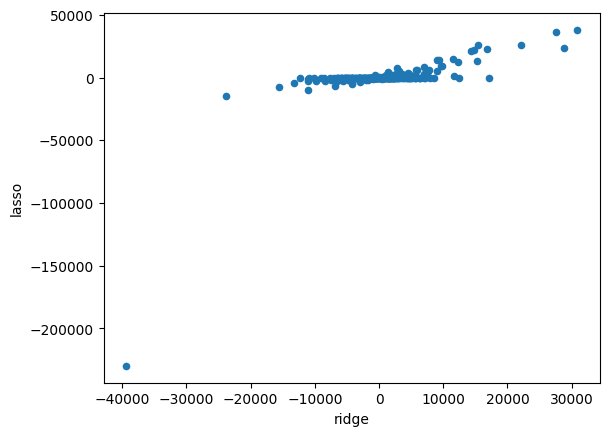

In [107]:
coef_compare.plot.scatter(x="ridge", y = "lasso")

# Part 4

In [91]:
# tuning the elastic pipeline
elastic_pipeline_1 = Pipeline(
  [("preprocessing", ct),
  ("elastic_net", ElasticNet())]
).set_output(transform="pandas")

param_grid = {
    "elastic_net__alpha": [1, 10, 100],
    "elastic_net__l1_ratio": np.arange(0.0, 1.2, 0.2),
}

gscv = GridSearchCV(elastic_pipeline_1, param_grid=param_grid, cv = 5, scoring='r2')

In [92]:
# feed in data
gscv_fitted_elastic = gscv.fit(X, y)

gscv_fitted_elastic.cv_results_

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.919e+12, tolerance: 1.348e+09 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.089e+12, tolerance: 1.474e+09 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

{'mean_fit_time': array([1.27577214, 0.10259466, 0.10199432, 0.11133657, 0.12185216,
        0.65934567, 1.26989942, 0.08411469, 0.08203688, 0.08225365,
        0.08718009, 0.26910138, 0.83210487, 0.08310394, 0.10893569,
        0.11073356, 0.11211576, 0.23271904]),
 'std_fit_time': array([0.68838496, 0.00584974, 0.00224669, 0.0044896 , 0.00690258,
        0.1148425 , 0.58677436, 0.00769925, 0.00175084, 0.00250125,
        0.00527322, 0.08816949, 0.0456894 , 0.01326656, 0.00726782,
        0.00467041, 0.01325005, 0.01296543]),
 'mean_score_time': array([0.03619175, 0.03341589, 0.03389859, 0.03319116, 0.03254504,
        0.03241553, 0.03929238, 0.03319545, 0.03211703, 0.03550262,
        0.03640943, 0.03286719, 0.03360839, 0.04584274, 0.06445594,
        0.06541758, 0.06004596, 0.03305984]),
 'std_score_time': array([0.00661785, 0.00197246, 0.00223582, 0.00031567, 0.00119708,
        0.00034241, 0.01269963, 0.00161168, 0.00046834, 0.00652397,
        0.00804162, 0.00101415, 0.00233238, 

In [93]:
# view results
df_cv_results_ = pd.DataFrame(gscv_fitted_elastic.cv_results_)

df_cv_results_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_elastic_net__alpha,param_elastic_net__l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.275772,0.688385,0.036192,0.006618,1,0.0,"{'elastic_net__alpha': 1, 'elastic_net__l1_rat...",0.819310,0.873470,0.775538,0.734519,0.857822,0.812132,0.051506,8
1,0.102595,0.005850,0.033416,0.001972,1,0.2,"{'elastic_net__alpha': 1, 'elastic_net__l1_rat...",0.830470,0.881659,0.778866,0.739074,0.866618,0.819337,0.053523,7
2,0.101994,0.002247,0.033899,0.002236,1,0.4,"{'elastic_net__alpha': 1, 'elastic_net__l1_rat...",0.842222,0.890269,0.781719,0.743712,0.876022,0.826789,0.055902,6
3,0.111337,0.004490,0.033191,0.000316,1,0.6,"{'elastic_net__alpha': 1, 'elastic_net__l1_rat...",0.854984,0.899709,0.784092,0.748899,0.886498,0.834836,0.058726,5
4,0.121852,0.006903,0.032545,0.001197,1,0.8,"{'elastic_net__alpha': 1, 'elastic_net__l1_rat...",0.869985,0.910922,0.786466,0.756417,0.899221,0.844602,0.061939,4
5,0.659346,0.114842,0.032416,0.000342,1,1.0,"{'elastic_net__alpha': 1, 'elastic_net__l1_rat...",0.897744,0.910938,0.796918,0.774262,0.905899,0.857152,0.059018,3
6,1.269899,0.586774,0.039292,0.012700,10,0.0,"{'elastic_net__alpha': 10, 'elastic_net__l1_ra...",0.492511,0.578344,0.541161,0.505391,0.563972,0.536276,0.032954,13
7,0.084115,0.007699,0.033195,0.001612,10,0.2,"{'elastic_net__alpha': 10, 'elastic_net__l1_ra...",0.543978,0.630330,0.587613,0.549154,0.615216,0.585258,0.034473,12
8,0.082037,0.001751,0.032117,0.000468,10,0.4,"{'elastic_net__alpha': 10, 'elastic_net__l1_ra...",0.605470,0.690470,0.640126,0.598959,0.674490,0.641903,0.036319,11
9,0.082254,0.002501,0.035503,0.006524,10,0.6,"{'elastic_net__alpha': 10, 'elastic_net__l1_ra...",0.679356,0.759111,0.697470,0.654039,0.742257,0.706446,0.039030,10


In [94]:
y_pred = gscv_fitted_elastic.predict(X)
# Grid Search automatically saves the best result!
# So this .predict() function call uses the optimized model automatically!

In [95]:
target = pd.DataFrame()

target["actual"] = y
target["predicted"] = y_pred

target

,actual,predicted
0,215000,218388.243679
1,105000,117726.828123
2,172000,65809.498269
3,244000,274770.257070
4,189900,179516.735946
...,...,...
2925,142500,158534.160801
2926,131000,138474.266725
2927,132000,107452.537001
2928,170000,176715.713297


<Axes: xlabel='actual', ylabel='predicted'>

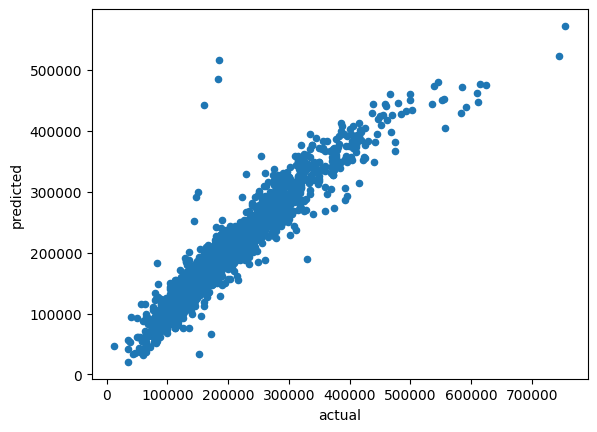

In [96]:
target.plot.scatter(x = "actual", y = "predicted")

In [97]:
# run as an elastic net using best performing parameters from grid search
elastic_pipeline = Pipeline(
  [("preprocessing", ct),
  ("elastic_net", ElasticNet(alpha=100, l1_ratio=0.1))]
)

In [98]:
# saving fitted elastic net pipeline
elastic_pipeline_fitted = elastic_pipeline.fit(X, y)
elastic_pipeline_fitted

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b9aeeb4c890>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b9aeeb4c6e0>)])),
                ('elastic_net', ElasticNet(alpha=100, l1_ratio=0.1))])

In [108]:
# adding elastic column to existing compmarison df
coef_compare["elastic"] = elastic_pipeline_fitted.named_steps['elastic_net'].coef_
coef_compare["elastic_lr__diff"] = coef_compare["elastic"] - coef_compare["lr"]
coef_compare["elastic__ridge_diff"] = coef_compare["elastic"] - coef_compare["ridge"]

In [109]:
coef_compare.sort_values(by = "elastic__ridge_diff")

,lr,ridge,ridge__lr_diff,lasso,lasso__lr_diff,lasso___ridge_diff,elastic,elastic_lr__diff,elastic__ridge_diff
52,35094.031373,30824.265938,-4269.765434,37996.392814,-2902.361442,-7172.126876,26.942248,-35067.089125,-30797.323690
98,118966.036255,28860.843083,-90105.193172,23941.338924,95024.697332,4919.504160,4.964610,-118961.071646,-28855.878474
45,23073.438286,27516.898277,4443.459991,36380.104189,-13306.665903,-8863.205912,38.622750,-23034.815536,-27478.275527
46,17323.198503,22092.527380,4769.328877,26189.381395,-8866.182892,-4096.854015,83.466936,-17239.731567,-22009.060444
67,56808.895075,17124.821375,-39684.073700,0.000000,56808.895075,17124.821375,3.857475,-56805.037599,-17120.963899
...,...,...,...,...,...,...,...,...,...
10,-169.659499,-12286.553661,-12116.894162,-0.000000,-169.659499,-12286.553661,2.009111,171.668610,12288.562772
44,-21346.959696,-13255.388914,8091.570781,-4437.987896,-16908.971799,-8817.401018,2.139726,21349.099422,13257.528641
34,-21714.739466,-15581.927229,6132.812237,-7394.806671,-14319.932795,-8187.120557,-30.785892,21683.953574,15551.141337
68,-113384.181772,-23831.619604,89552.562168,-14419.743900,-98964.437873,-9411.875704,2.187280,113386.369053,23833.806884
